In [1]:
# ============================================================
# PHASE 19 — EXTERNAL / INDEPENDENT GENE-SET VALIDATION
# ============================================================
# Goal:
# Evaluate whether model rankings recover independently supported
# T2D-relevant genes and biological themes.
#
# Main idea:
# 1. Use out-of-fold predictions from Phase 17.
# 2. Aggregate prediction scores per gene per model.
# 3. Compare top-ranked genes against independent external gene sets:
#    - known T2D / GWAS genes
#    - beta-cell function genes
#    - glucose metabolism / insulin secretion genes
#    - diabetes drug target genes
#    - mitochondrial / OXPHOS genes
# 4. Use random gene-set baselines and empirical p-values.
# 5. Identify external-supported current-negative genes as
#    hypothesis-generating candidates.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 400)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
SHARED_DIR = PHASE3_DIR / "shared_dataset"

PHASE17_DIR = PROJECT_DIR / "model" / "phase17_repeated_cross_validation_robust_benchmark"
PHASE18_DIR = PROJECT_DIR / "model" / "phase18_negative_set_sensitivity_analysis"
PHASE15_DIR = PROJECT_DIR / "model" / "phase15_biological_literature_support"

PHASE19_DIR = PROJECT_DIR / "model" / "phase19_external_independent_gene_set_validation"
RESULT_DIR = PHASE19_DIR / "results"
FIGURE_DIR = PHASE19_DIR / "figures"
EXCEL_DIR = PHASE19_DIR / "excel"
REPORT_DIR = PHASE19_DIR / "reports"
EXTERNAL_DIR = PHASE19_DIR / "external_gene_sets"

for d in [PHASE19_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR, EXTERNAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 19 output:", PHASE19_DIR)

Mounted at /content/drive
Phase 19 output: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=5):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def clean_gene_symbol(x):
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    if s == "" or s in ["NAN", "NONE", "NULL"]:
        return None
    return s


def find_gene_column(df):
    candidates = [
        "gene_symbol", "gene", "Gene", "symbol", "gene_name",
        "hgnc_symbol", "approved_symbol", "target"
    ]
    for c in candidates:
        if c in df.columns:
            return c

    object_cols = [c for c in df.columns if df[c].dtype == "object"]
    pat = re.compile(r"^[A-Z0-9\-]{2,20}$")

    best_col = None
    best_score = -1

    for c in object_cols:
        vals = df[c].dropna().astype(str).head(500).tolist()
        score = sum(bool(pat.match(v.strip().upper())) for v in vals)
        if score > best_score:
            best_col = c
            best_score = score

    return best_col


def find_label_column(df):
    candidates = ["label", "y", "target", "class", "is_positive", "t2d_label"]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def empirical_p_value(observed, random_values, alternative="greater"):
    random_values = np.asarray(random_values)

    if alternative == "greater":
        return (np.sum(random_values >= observed) + 1) / (len(random_values) + 1)

    if alternative == "less":
        return (np.sum(random_values <= observed) + 1) / (len(random_values) + 1)

    raise ValueError("alternative must be greater or less")


def bootstrap_ci_mean(values, n_boot=3000, seed=42, ci=95):
    rng_local = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)

    boots = []
    for _ in range(n_boot):
        boots.append(np.mean(rng_local.choice(values, size=len(values), replace=True)))

    alpha = (100 - ci) / 2
    return (
        float(np.percentile(boots, alpha)),
        float(np.percentile(boots, 100 - alpha))
    )


def safe_mannwhitneyu(a, b):
    try:
        stat, p = mannwhitneyu(a, b, alternative="two-sided")
        return stat, p
    except Exception:
        return np.nan, np.nan

In [3]:
# ============================================================
# LOAD LABELS AND SAMPLE METADATA
# ============================================================

y_train = np.load(SHARED_DIR / "y_train_multimodal_v1.npy").astype(int)
y_val   = np.load(SHARED_DIR / "y_val_multimodal_v1.npy").astype(int)
y_test  = np.load(SHARED_DIR / "y_test_multimodal_v1.npy").astype(int)

y_full = np.concatenate([y_train, y_val, y_test]).astype(int)

print("Labels:", y_full.shape, np.bincount(y_full))

# Prefer metadata from Phase 18 if available
phase18_metadata_path = PHASE18_DIR / "results" / "phase18_sample_metadata_used.csv"

if phase18_metadata_path.exists():
    sample_metadata_df = pd.read_csv(phase18_metadata_path)
    print("Loaded metadata from Phase 18:", phase18_metadata_path)
else:
    # Search possible metadata files
    metadata_candidates = []

    patterns = [
        "*metadata*.csv",
        "*sample*.csv",
        "*split*.csv",
        "*dataset*.csv",
        "*gene*.csv",
        "*multimodal*.csv"
    ]

    for pattern in patterns:
        for path in PROJECT_DIR.rglob(pattern):
            try:
                if path.stat().st_size > 100 * 1024 * 1024:
                    continue
                df = pd.read_csv(path)
                if len(df) == len(y_full):
                    metadata_candidates.append(path)
            except Exception:
                pass

    if metadata_candidates:
        sample_metadata_df = pd.read_csv(metadata_candidates[0])
        print("Loaded metadata candidate:", metadata_candidates[0])
    else:
        sample_metadata_df = pd.DataFrame({
            "sample_index": np.arange(len(y_full)),
            "gene_symbol": [f"SAMPLE_{i}" for i in range(len(y_full))],
            "label": y_full
        })
        print("No metadata found. Created generic metadata.")

sample_metadata_df = sample_metadata_df.reset_index(drop=True)

if "sample_index" not in sample_metadata_df.columns:
    sample_metadata_df["sample_index"] = np.arange(len(sample_metadata_df))

gene_col = find_gene_column(sample_metadata_df)
if gene_col is None:
    sample_metadata_df["gene_symbol"] = [f"SAMPLE_{i}" for i in range(len(sample_metadata_df))]
else:
    sample_metadata_df["gene_symbol"] = sample_metadata_df[gene_col].apply(clean_gene_symbol)

label_col = find_label_column(sample_metadata_df)
if label_col is None:
    sample_metadata_df["label"] = y_full
else:
    sample_metadata_df["label"] = sample_metadata_df[label_col].astype(int)

sample_metadata_df["label_from_array"] = y_full
sample_metadata_df["label_match"] = sample_metadata_df["label"].astype(int) == sample_metadata_df["label_from_array"].astype(int)

display(sample_metadata_df.head())
display(sample_metadata_df["label_match"].value_counts())

n_generic = sample_metadata_df["gene_symbol"].astype(str).str.startswith("SAMPLE_").sum()
print("Generic gene symbols:", n_generic, "/", len(sample_metadata_df))

save_df(sample_metadata_df, RESULT_DIR / "phase19_sample_metadata_used.csv")

if n_generic > len(sample_metadata_df) * 0.5:
    print("WARNING: Gene symbols look generic. External gene-set validation requires real gene symbols.")

Labels: (1806,) [903 903]
Loaded metadata from Phase 18: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_sample_metadata_used.csv


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,sample_index,label_from_array
0,ENSG00000205155,PSENEN,0,0,train,PSENEN,0,1589,test,True,0,PSENEN,0,0
1,ENSG00000164530,PI16,1,1,train,PI16,1,250,train,True,1,PI16,1,1
2,ENSG00000143167,GPA33,0,2,train,GPA33,0,1634,test,True,0,GPA33,2,0
3,ENSG00000137691,CFAP300,0,3,train,CFAP300,0,511,train,True,0,CFAP300,3,0
4,ENSG00000095981,KCNK16,1,4,train,KCNK16,1,837,train,True,1,KCNK16,4,1


,count
label_match,
True,942
False,864


Generic gene symbols: 0 / 1806
Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_sample_metadata_used.csv


In [4]:
# ============================================================
# LOAD PHASE 17 OUT-OF-FOLD PREDICTIONS
# ============================================================

phase17_pred_path = PHASE17_DIR / "results" / "phase17_repeated_cv_all_predictions.csv"

assert phase17_pred_path.exists(), f"Missing Phase 17 predictions: {phase17_pred_path}"

phase17_pred_df = pd.read_csv(phase17_pred_path)

print("Loaded Phase 17 predictions:", phase17_pred_df.shape)
display(phase17_pred_df.head())

# Attach gene symbols and labels
phase17_pred_df = phase17_pred_df.merge(
    sample_metadata_df[["sample_index", "gene_symbol", "label"]],
    on="sample_index",
    how="left",
    suffixes=("", "_metadata")
)

phase17_pred_df["gene_symbol"] = phase17_pred_df["gene_symbol"].apply(clean_gene_symbol)

display(phase17_pred_df.head())

save_df(phase17_pred_df, RESULT_DIR / "phase19_phase17_predictions_with_gene_symbols.csv")

Loaded Phase 17 predictions: (36120, 7)


,split_id,model_name,sample_index,true_label,score,threshold,pred_label
0,1,Genomic_only_K3K4Basic,0,0,0.484778,0.544261,0
1,1,Genomic_only_K3K4Basic,7,0,0.466675,0.544261,0
2,1,Genomic_only_K3K4Basic,14,0,0.568181,0.544261,1
3,1,Genomic_only_K3K4Basic,16,0,0.415888,0.544261,0
4,1,Genomic_only_K3K4Basic,18,0,0.625825,0.544261,1


,split_id,model_name,sample_index,true_label,score,threshold,pred_label,gene_symbol,label
0,1,Genomic_only_K3K4Basic,0,0,0.484778,0.544261,0,PSENEN,0
1,1,Genomic_only_K3K4Basic,7,0,0.466675,0.544261,0,MOSMO,0
2,1,Genomic_only_K3K4Basic,14,0,0.568181,0.544261,1,KCNK17,1
3,1,Genomic_only_K3K4Basic,16,0,0.415888,0.544261,0,SMIM39,0
4,1,Genomic_only_K3K4Basic,18,0,0.625825,0.544261,1,PNOC,1


Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_phase17_predictions_with_gene_symbols.csv


In [5]:
# ============================================================
# AGGREGATE OUT-OF-FOLD SCORES PER GENE AND MODEL
# ============================================================

rank_records = []

for model_name, sub in phase17_pred_df.groupby("model_name"):
    agg = (
        sub.groupby(["sample_index", "gene_symbol"], as_index=False)
        .agg(
            true_label=("true_label", "first"),
            mean_oof_score=("score", "mean"),
            sd_oof_score=("score", "std"),
            n_oof_predictions=("score", "count")
        )
    )

    agg["model_name"] = model_name
    agg["rank_desc"] = agg["mean_oof_score"].rank(ascending=False, method="min").astype(int)
    agg["percentile_rank"] = 1 - ((agg["rank_desc"] - 1) / (len(agg) - 1))

    rank_records.append(agg)

gene_rank_df = pd.concat(rank_records, ignore_index=True)

# Add display names
model_display_map = {
    "Genomic_only_K3K4Basic": "Genomic-only",
    "Protein_only_ProtBERT_SW": "Protein-only",
    "Handcrafted_multimodal": "Handcrafted multimodal",
    "DNABERT2_multimodal": "DNABERT-2 multimodal"
}

gene_rank_df["display_name"] = gene_rank_df["model_name"].map(model_display_map).fillna(gene_rank_df["model_name"])

gene_rank_df = gene_rank_df.sort_values(["model_name", "rank_desc"]).reset_index(drop=True)
gene_rank_df = round_numeric_columns(gene_rank_df, 6)

display(gene_rank_df.head(20))

save_df(gene_rank_df, RESULT_DIR / "phase19_gene_level_oof_rankings_by_model.csv")

,sample_index,gene_symbol,true_label,mean_oof_score,sd_oof_score,n_oof_predictions,model_name,rank_desc,percentile_rank,display_name
0,386,ATP4B,1,0.897893,0.018568,5,DNABERT2_multimodal,1,1.000000,DNABERT-2 multimodal
1,1701,GRM8,1,0.892079,0.013946,5,DNABERT2_multimodal,2,0.999446,DNABERT-2 multimodal
2,21,NEXMIF,0,0.890804,0.024677,5,DNABERT2_multimodal,3,0.998892,DNABERT-2 multimodal
3,479,HAUS6,0,0.889759,0.007953,5,DNABERT2_multimodal,4,0.998338,DNABERT-2 multimodal
4,454,ZC3H13,1,0.881700,0.005782,5,DNABERT2_multimodal,5,0.997784,DNABERT-2 multimodal
5,1685,RBM27,1,0.879396,0.026239,5,DNABERT2_multimodal,6,0.997230,DNABERT-2 multimodal
6,1161,PNLIP,0,0.877368,0.021020,5,DNABERT2_multimodal,7,0.996676,DNABERT-2 multimodal
7,575,MLXIPL,1,0.876813,0.009338,5,DNABERT2_multimodal,8,0.996122,DNABERT-2 multimodal
8,634,DENND2A,1,0.876118,0.019472,5,DNABERT2_multimodal,9,0.995568,DNABERT-2 multimodal
9,1188,RAET1L,1,0.875945,0.027268,5,DNABERT2_multimodal,10,0.995014,DNABERT-2 multimodal


Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_gene_level_oof_rankings_by_model.csv


In [6]:
# ============================================================
# DEFINE EXTERNAL / INDEPENDENT GENE SETS
# ============================================================
# You can add your own external CSV files into:
# /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/external_gene_sets
#
# Expected CSV format:
# gene_symbol
# INSR
# PDX1
# ...
#
# The code also includes conservative curated fallback gene sets.
# ============================================================

external_gene_sets = {
    "Known_T2D_GWAS_or_genetic_risk": [
        "TCF7L2", "PPARG", "KCNJ11", "SLC30A8", "HHEX", "CDKAL1",
        "CDKN2A", "CDKN2B", "IGF2BP2", "FTO", "WFS1", "MTNR1B",
        "JAZF1", "CDC123", "CAMK1D", "TSPAN8", "LGR5", "THADA",
        "ADAMTS9", "NOTCH2", "IRS1", "KCNQ1", "PROX1", "GCK",
        "GCKR", "DGKB", "GIPR", "ADCY5", "GLIS3", "MAEA",
        "INSR", "DUSP9", "HMGA2", "GRB14", "TP53INP1"
    ],
    "Beta_cell_function_or_development": [
        "PDX1", "NEUROD1", "MAFA", "NKX6-1", "NKX2-2", "PAX4",
        "PAX6", "ISL1", "HNF1A", "HNF1B", "HNF4A", "GCK",
        "KCNJ11", "ABCC8", "SLC30A8", "INS", "IAPP", "PCSK1",
        "GLIS3", "MTNR1B", "CACNA1D", "GAD1"
    ],
    "Glucose_metabolism_transport_or_insulin_secretion": [
        "INSR", "IRS1", "IRS2", "AKT2", "PIK3R1", "GCK", "GCKR",
        "SLC2A2", "SLC2A4", "SLC5A1", "SLC5A2", "KCNJ11",
        "ABCC8", "DPP4", "GIPR", "GLP1R", "PCSK1", "PCK1",
        "G6PC2", "HK1", "HK2"
    ],
    "Diabetes_drug_targets_or_pharmacology": [
        "DPP4", "GLP1R", "SLC5A2", "PPARG", "KCNJ11", "ABCC8",
        "INSR", "GIPR", "PTPN1", "MGAM", "AGL", "GCK"
    ],
    "Mitochondrial_OXPHOS_complex_I": [
        "NDUFA1", "NDUFA2", "NDUFA3", "NDUFA4", "NDUFA5",
        "NDUFA6", "NDUFA7", "NDUFA8", "NDUFA9", "NDUFA10",
        "NDUFA11", "NDUFA12", "NDUFA13",
        "NDUFB1", "NDUFB2", "NDUFB3", "NDUFB4", "NDUFB5",
        "NDUFB6", "NDUFB7", "NDUFB8", "NDUFB9", "NDUFB10",
        "NDUFB11",
        "NDUFS1", "NDUFS2", "NDUFS3", "NDUFS4", "NDUFS5",
        "NDUFS6", "NDUFS7", "NDUFS8",
        "NDUFV1", "NDUFV2", "NDUFV3"
    ]
}

# Load additional user-provided external gene sets
external_file_records = []

for path in EXTERNAL_DIR.glob("*.csv"):
    try:
        df = pd.read_csv(path)
        gcol = find_gene_column(df)
        if gcol is None:
            continue

        genes = sorted(set([clean_gene_symbol(x) for x in df[gcol].tolist() if clean_gene_symbol(x)]))
        set_name = path.stem

        external_gene_sets[set_name] = genes

        external_file_records.append({
            "file": str(path),
            "set_name": set_name,
            "n_genes": len(genes)
        })

    except Exception as e:
        print("Could not load external gene set:", path, e)

external_file_df = pd.DataFrame(external_file_records)

print("External gene sets:")
for k, v in external_gene_sets.items():
    print(k, len(v), v[:10])

if not external_file_df.empty:
    display(external_file_df)

save_df(external_file_df, RESULT_DIR / "phase19_loaded_external_gene_set_files.csv")

External gene sets:
Known_T2D_GWAS_or_genetic_risk 35 ['TCF7L2', 'PPARG', 'KCNJ11', 'SLC30A8', 'HHEX', 'CDKAL1', 'CDKN2A', 'CDKN2B', 'IGF2BP2', 'FTO']
Beta_cell_function_or_development 22 ['PDX1', 'NEUROD1', 'MAFA', 'NKX6-1', 'NKX2-2', 'PAX4', 'PAX6', 'ISL1', 'HNF1A', 'HNF1B']
Glucose_metabolism_transport_or_insulin_secretion 21 ['INSR', 'IRS1', 'IRS2', 'AKT2', 'PIK3R1', 'GCK', 'GCKR', 'SLC2A2', 'SLC2A4', 'SLC5A1']
Diabetes_drug_targets_or_pharmacology 12 ['DPP4', 'GLP1R', 'SLC5A2', 'PPARG', 'KCNJ11', 'ABCC8', 'INSR', 'GIPR', 'PTPN1', 'MGAM']
Mitochondrial_OXPHOS_complex_I 35 ['NDUFA1', 'NDUFA2', 'NDUFA3', 'NDUFA4', 'NDUFA5', 'NDUFA6', 'NDUFA7', 'NDUFA8', 'NDUFA9', 'NDUFA10']
Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_loaded_external_gene_set_files.csv


In [7]:
# ============================================================
# CREATE EXTERNAL GENE-SET TABLE
# ============================================================

external_records = []

for set_name, genes in external_gene_sets.items():
    genes_clean = sorted(set([clean_gene_symbol(g) for g in genes if clean_gene_symbol(g)]))

    for g in genes_clean:
        external_records.append({
            "gene_symbol": g,
            "external_set": set_name
        })

external_gene_set_df = pd.DataFrame(external_records).drop_duplicates()

# Candidate universe
candidate_genes = set(gene_rank_df["gene_symbol"].dropna().astype(str).tolist())
external_gene_set_df["in_candidate_universe"] = external_gene_set_df["gene_symbol"].isin(candidate_genes)

external_coverage_df = (
    external_gene_set_df
    .groupby("external_set", as_index=False)
    .agg(
        n_external_genes=("gene_symbol", "nunique"),
        n_in_candidate_universe=("in_candidate_universe", "sum"),
        genes_in_candidate_universe=("gene_symbol", lambda x: "; ".join([g for g in sorted(set(x)) if g in candidate_genes]))
    )
)

external_coverage_df["coverage_rate"] = (
    external_coverage_df["n_in_candidate_universe"] /
    external_coverage_df["n_external_genes"]
)

external_coverage_df = round_numeric_columns(external_coverage_df, 4)

display(external_coverage_df)

save_df(external_gene_set_df, RESULT_DIR / "phase19_external_gene_set_long.csv")
save_df(external_coverage_df, RESULT_DIR / "phase19_external_gene_set_coverage.csv")

,external_set,n_external_genes,n_in_candidate_universe,genes_in_candidate_universe,coverage_rate
0,Beta_cell_function_or_development,22,18,ABCC8; CACNA1D; GAD1; GCK; GLIS3; HNF1A; HNF1B; HNF4A; INS; ISL1; KCNJ11; MTNR1B; NEUROD1; NKX6-1; PAX4; PCSK1; PDX1; SLC30A8,0.8182
1,Diabetes_drug_targets_or_pharmacology,12,10,ABCC8; DPP4; GCK; GIPR; GLP1R; INSR; KCNJ11; MGAM; PPARG; SLC5A2,0.8333
2,Glucose_metabolism_transport_or_insulin_secretion,21,18,ABCC8; AKT2; DPP4; G6PC2; GCK; GCKR; GIPR; GLP1R; HK1; INSR; IRS1; IRS2; KCNJ11; PCSK1; PIK3R1; SLC2A2; SLC5A1; SLC5A2,0.8571
3,Known_T2D_GWAS_or_genetic_risk,35,33,ADAMTS9; ADCY5; CAMK1D; CDC123; CDKAL1; CDKN2B; DGKB; DUSP9; FTO; GCK; GCKR; GIPR; GLIS3; GRB14; HHEX; HMGA2; IGF2BP2; INSR; IRS1; JAZF1; KCNJ11; KCNQ1; MAEA; MTNR1B; NOTCH2; PPARG; PROX1; SLC30A8; TCF7L2; THADA; TP53INP1; TSPAN8; WFS1,0.9429
4,Mitochondrial_OXPHOS_complex_I,35,34,NDUFA1; NDUFA10; NDUFA11; NDUFA12; NDUFA13; NDUFA2; NDUFA3; NDUFA5; NDUFA6; NDUFA7; NDUFA8; NDUFA9; NDUFB1; NDUFB10; NDUFB11; NDUFB2; NDUFB3; NDUFB4; NDUFB5; NDUFB6; NDUFB7; NDUFB8; NDUFB9; NDUFS1; NDUFS2; NDUFS3; NDUFS4; NDUFS5; NDUFS6; NDUFS7; NDUFS8; NDUFV1; NDUFV2; NDUFV3,0.9714


Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_external_gene_set_long.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_external_gene_set_coverage.csv


In [8]:
# ============================================================
# TOP-N EXTERNAL OVERLAP WITH RANDOM BASELINE
# ============================================================

TOP_N_LIST = [25, 50, 100, 150, 200]
N_RANDOM = 5000

overlap_records = []

for model_name, sub_model in gene_rank_df.groupby("model_name"):
    sub_model = sub_model.sort_values("rank_desc").reset_index(drop=True)

    universe_genes = sub_model["gene_symbol"].dropna().astype(str).unique().tolist()
    universe_set = set(universe_genes)

    for external_set, ext_df in external_gene_set_df.groupby("external_set"):
        external_genes = set(ext_df.loc[ext_df["in_candidate_universe"], "gene_symbol"].astype(str).tolist())
        external_genes = external_genes.intersection(universe_set)

        if len(external_genes) == 0:
            continue

        for top_n in TOP_N_LIST:
            top_genes = set(sub_model.head(top_n)["gene_symbol"].astype(str).tolist())
            observed = len(top_genes.intersection(external_genes))

            random_counts = []
            for _ in range(N_RANDOM):
                rand_genes = set(rng.choice(universe_genes, size=top_n, replace=False))
                random_counts.append(len(rand_genes.intersection(external_genes)))

            random_counts = np.asarray(random_counts)
            random_mean = float(np.mean(random_counts))
            random_sd = float(np.std(random_counts, ddof=1))
            p_emp = empirical_p_value(observed, random_counts, alternative="greater")

            enrichment_fold = (
                observed / random_mean if random_mean > 0 else np.nan
            )

            overlap_records.append({
                "model_name": model_name,
                "display_name": model_display_map.get(model_name, model_name),
                "external_set": external_set,
                "top_n": top_n,
                "observed_overlap": observed,
                "external_genes_in_universe": len(external_genes),
                "random_mean": random_mean,
                "random_sd": random_sd,
                "enrichment_fold_vs_random": enrichment_fold,
                "empirical_p": p_emp,
                "top_genes_overlap": "; ".join(sorted(top_genes.intersection(external_genes)))
            })

topn_overlap_df = pd.DataFrame(overlap_records)

# BH-FDR globally and within top_n
topn_overlap_df["empirical_bh_fdr_global"] = multipletests(
    topn_overlap_df["empirical_p"],
    method="fdr_bh"
)[1]

topn_overlap_df["empirical_bh_fdr_within_topn"] = np.nan

for top_n, sub in topn_overlap_df.groupby("top_n"):
    idx = sub.index
    topn_overlap_df.loc[idx, "empirical_bh_fdr_within_topn"] = multipletests(
        sub["empirical_p"],
        method="fdr_bh"
    )[1]

topn_overlap_df = round_numeric_columns(topn_overlap_df, 5)

display(topn_overlap_df.head(50))

save_df(topn_overlap_df, RESULT_DIR / "phase19_topn_external_gene_set_overlap_random_baseline.csv")

,model_name,display_name,external_set,top_n,observed_overlap,external_genes_in_universe,random_mean,random_sd,enrichment_fold_vs_random,empirical_p,top_genes_overlap,empirical_bh_fdr_global,empirical_bh_fdr_within_topn
0,DNABERT2_multimodal,DNABERT-2 multimodal,Beta_cell_function_or_development,25,1,18,0.2444,0.48447,4.09165,0.22076,NKX6-1,1.0,1.00000
1,DNABERT2_multimodal,DNABERT-2 multimodal,Beta_cell_function_or_development,50,1,18,0.4952,0.69460,2.01939,0.39412,NKX6-1,1.0,0.95673
2,DNABERT2_multimodal,DNABERT-2 multimodal,Beta_cell_function_or_development,100,1,18,1.0006,0.97938,0.99940,0.63867,NKX6-1,1.0,1.00000
3,DNABERT2_multimodal,DNABERT-2 multimodal,Beta_cell_function_or_development,150,1,18,1.4776,1.15159,0.67677,0.78944,NKX6-1,1.0,0.93158
4,DNABERT2_multimodal,DNABERT-2 multimodal,Beta_cell_function_or_development,200,1,18,1.9572,1.31458,0.51093,0.87542,NKX6-1,1.0,0.93876
5,DNABERT2_multimodal,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology,25,0,10,0.1448,0.37876,0.00000,1.00000,,1.0,1.00000
6,DNABERT2_multimodal,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology,50,0,10,0.2900,0.52455,0.00000,1.00000,,1.0,1.00000
7,DNABERT2_multimodal,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology,100,0,10,0.5500,0.72111,0.00000,1.00000,,1.0,1.00000
8,DNABERT2_multimodal,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology,150,0,10,0.8138,0.86144,0.00000,1.00000,,1.0,1.00000
9,DNABERT2_multimodal,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology,200,0,10,1.0864,0.98444,0.00000,1.00000,,1.0,1.00000


Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_topn_external_gene_set_overlap_random_baseline.csv


In [9]:
# ============================================================
# RANK-DISTRIBUTION TEST FOR EXTERNAL GENES
# ============================================================

rank_test_records = []

for model_name, sub_model in gene_rank_df.groupby("model_name"):
    universe_genes = set(sub_model["gene_symbol"].dropna().astype(str).tolist())

    for external_set, ext_df in external_gene_set_df.groupby("external_set"):
        external_genes = set(ext_df.loc[ext_df["in_candidate_universe"], "gene_symbol"].astype(str).tolist())
        external_genes = external_genes.intersection(universe_genes)

        if len(external_genes) < 2:
            continue

        tmp = sub_model.copy()
        tmp["is_external"] = tmp["gene_symbol"].isin(external_genes)

        ext_scores = tmp.loc[tmp["is_external"], "mean_oof_score"].values
        non_scores = tmp.loc[~tmp["is_external"], "mean_oof_score"].values

        ext_ranks = tmp.loc[tmp["is_external"], "rank_desc"].values
        non_ranks = tmp.loc[~tmp["is_external"], "rank_desc"].values

        stat_score, p_score = safe_mannwhitneyu(ext_scores, non_scores)
        stat_rank, p_rank = safe_mannwhitneyu(-ext_ranks, -non_ranks)

        rank_test_records.append({
            "model_name": model_name,
            "display_name": model_display_map.get(model_name, model_name),
            "external_set": external_set,
            "n_external_in_universe": len(external_genes),
            "mean_score_external": np.mean(ext_scores),
            "mean_score_non_external": np.mean(non_scores),
            "median_rank_external": np.median(ext_ranks),
            "median_rank_non_external": np.median(non_ranks),
            "mannwhitney_score_p": p_score,
            "mannwhitney_rank_p": p_rank,
            "external_genes_in_universe": "; ".join(sorted(external_genes))
        })

rank_distribution_df = pd.DataFrame(rank_test_records)

rank_distribution_df["score_bh_fdr"] = multipletests(
    rank_distribution_df["mannwhitney_score_p"],
    method="fdr_bh"
)[1]

rank_distribution_df["rank_bh_fdr"] = multipletests(
    rank_distribution_df["mannwhitney_rank_p"],
    method="fdr_bh"
)[1]

rank_distribution_df = round_numeric_columns(rank_distribution_df, 5)

display(rank_distribution_df)

save_df(rank_distribution_df, RESULT_DIR / "phase19_external_gene_rank_distribution_tests.csv")

,model_name,display_name,external_set,n_external_in_universe,mean_score_external,mean_score_non_external,median_rank_external,median_rank_non_external,mannwhitney_score_p,mannwhitney_rank_p,external_genes_in_universe,score_bh_fdr,rank_bh_fdr
0,DNABERT2_multimodal,DNABERT-2 multimodal,Beta_cell_function_or_development,18,0.45146,0.50013,1127.0,900.5,0.28137,0.28137,ABCC8; CACNA1D; GAD1; GCK; GLIS3; HNF1A; HNF1B; HNF4A; INS; ISL1; KCNJ11; MTNR1B; NEUROD1; NKX6-1; PAX4; PCSK1; PDX1; SLC30A8,0.70708,0.70708
1,DNABERT2_multimodal,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology,10,0.53832,0.49943,552.5,904.5,0.50493,0.50493,ABCC8; DPP4; GCK; GIPR; GLP1R; INSR; KCNJ11; MGAM; PPARG; SLC5A2,0.70708,0.70708
2,DNABERT2_multimodal,DNABERT-2 multimodal,Glucose_metabolism_transport_or_insulin_secretion,18,0.47836,0.49986,1162.5,901.5,0.63194,0.63194,ABCC8; AKT2; DPP4; G6PC2; GCK; GCKR; GIPR; GLP1R; HK1; INSR; IRS1; IRS2; KCNJ11; PCSK1; PIK3R1; SLC2A2; SLC5A1; SLC5A2,0.70708,0.70708
3,DNABERT2_multimodal,DNABERT-2 multimodal,Known_T2D_GWAS_or_genetic_risk,33,0.51852,0.49929,891.0,904.0,0.55706,0.55706,ADAMTS9; ADCY5; CAMK1D; CDC123; CDKAL1; CDKN2B; DGKB; DUSP9; FTO; GCK; GCKR; GIPR; GLIS3; GRB14; HHEX; HMGA2; IGF2BP2; INSR; IRS1; JAZF1; KCNJ11; KCNQ1; MAEA; MTNR1B; NOTCH2; PPARG; PROX1; SLC30A8; TCF7L2; THADA; TP53INP1; TSPAN8; WFS1,0.70708,0.70708
4,DNABERT2_multimodal,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,34,0.54372,0.49880,665.5,907.5,0.18533,0.18533,NDUFA1; NDUFA10; NDUFA11; NDUFA12; NDUFA13; NDUFA2; NDUFA3; NDUFA5; NDUFA6; NDUFA7; NDUFA8; NDUFA9; NDUFB1; NDUFB10; NDUFB11; NDUFB2; NDUFB3; NDUFB4; NDUFB5; NDUFB6; NDUFB7; NDUFB8; NDUFB9; NDUFS1; NDUFS2; NDUFS3; NDUFS4; NDUFS5; NDUFS6; NDUFS7; NDUFS8; NDUFV1; NDUFV2; NDUFV3,0.70708,0.70708
5,Genomic_only_K3K4Basic,Genomic-only,Beta_cell_function_or_development,18,0.51520,0.50070,681.5,906.5,0.36699,0.36711,ABCC8; CACNA1D; GAD1; GCK; GLIS3; HNF1A; HNF1B; HNF4A; INS; ISL1; KCNJ11; MTNR1B; NEUROD1; NKX6-1; PAX4; PCSK1; PDX1; SLC30A8,0.70708,0.70708
6,Genomic_only_K3K4Basic,Genomic-only,Diabetes_drug_targets_or_pharmacology,10,0.51659,0.50076,702.0,905.5,0.51901,0.51901,ABCC8; DPP4; GCK; GIPR; GLP1R; INSR; KCNJ11; MGAM; PPARG; SLC5A2,0.70708,0.70708
7,Genomic_only_K3K4Basic,Genomic-only,Glucose_metabolism_transport_or_insulin_secretion,18,0.47599,0.50110,806.5,904.5,0.45643,0.45643,ABCC8; AKT2; DPP4; G6PC2; GCK; GCKR; GIPR; GLP1R; HK1; INSR; IRS1; IRS2; KCNJ11; PCSK1; PIK3R1; SLC2A2; SLC5A1; SLC5A2,0.70708,0.70708
8,Genomic_only_K3K4Basic,Genomic-only,Known_T2D_GWAS_or_genetic_risk,33,0.50845,0.50071,827.0,905.0,0.63489,0.63501,ADAMTS9; ADCY5; CAMK1D; CDC123; CDKAL1; CDKN2B; DGKB; DUSP9; FTO; GCK; GCKR; GIPR; GLIS3; GRB14; HHEX; HMGA2; IGF2BP2; INSR; IRS1; JAZF1; KCNJ11; KCNQ1; MAEA; MTNR1B; NOTCH2; PPARG; PROX1; SLC30A8; TCF7L2; THADA; TP53INP1; TSPAN8; WFS1,0.70708,0.70708
9,Genomic_only_K3K4Basic,Genomic-only,Mitochondrial_OXPHOS_complex_I,34,0.48456,0.50116,984.0,900.5,0.35663,0.35663,NDUFA1; NDUFA10; NDUFA11; NDUFA12; NDUFA13; NDUFA2; NDUFA3; NDUFA5; NDUFA6; NDUFA7; NDUFA8; NDUFA9; NDUFB1; NDUFB10; NDUFB11; NDUFB2; NDUFB3; NDUFB4; NDUFB5; NDUFB6; NDUFB7; NDUFB8; NDUFB9; NDUFS1; NDUFS2; NDUFS3; NDUFS4; NDUFS5; NDUFS6; NDUFS7; NDUFS8; NDUFV1; NDUFV2; NDUFV3,0.70708,0.70708


Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_external_gene_rank_distribution_tests.csv


In [10]:
# ============================================================
# EXTERNAL-SUPPORTED CURRENT-NEGATIVE CANDIDATES
# ============================================================
# These genes are labelled negative in the current dataset, but appear
# in external evidence sets. They should be treated as:
# "potentially mislabeled / unknown-positive / hypothesis-generating".
# ============================================================

external_union = set(external_gene_set_df.loc[
    external_gene_set_df["in_candidate_universe"], "gene_symbol"
].astype(str).tolist())

candidate_external_annotation = []

for gene in sorted(external_union):
    sets = sorted(external_gene_set_df.loc[
        external_gene_set_df["gene_symbol"] == gene, "external_set"
    ].unique().tolist())

    candidate_external_annotation.append({
        "gene_symbol": gene,
        "external_sets": "; ".join(sets),
        "n_external_sets": len(sets)
    })

candidate_external_annotation_df = pd.DataFrame(candidate_external_annotation)

external_rank_annotated_df = gene_rank_df.merge(
    candidate_external_annotation_df,
    on="gene_symbol",
    how="inner"
)

external_rank_annotated_df["is_current_negative"] = external_rank_annotated_df["true_label"].astype(int) == 0
external_rank_annotated_df["is_current_positive"] = external_rank_annotated_df["true_label"].astype(int) == 1

external_negative_candidates_df = external_rank_annotated_df[
    external_rank_annotated_df["is_current_negative"]
].copy()

external_negative_candidates_df = external_negative_candidates_df.sort_values(
    ["model_name", "rank_desc"]
).reset_index(drop=True)

display(external_negative_candidates_df.head(50))

save_df(
    external_rank_annotated_df,
    RESULT_DIR / "phase19_external_supported_genes_ranked_by_model.csv"
)

save_df(
    external_negative_candidates_df,
    RESULT_DIR / "phase19_external_supported_current_negative_candidates.csv"
)

,sample_index,gene_symbol,true_label,mean_oof_score,sd_oof_score,n_oof_predictions,model_name,rank_desc,percentile_rank,display_name,external_sets,n_external_sets,is_current_negative,is_current_positive
0,268,NDUFV1,0,0.808844,0.037659,5,DNABERT2_multimodal,95,0.947922,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
1,585,NDUFA12,0,0.806018,0.030543,5,DNABERT2_multimodal,98,0.946260,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
2,628,NDUFB10,0,0.762450,0.041657,5,DNABERT2_multimodal,198,0.890859,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
3,514,NDUFB5,0,0.700973,0.068433,5,DNABERT2_multimodal,354,0.804432,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
4,810,GIPR,0,0.679566,0.044854,5,DNABERT2_multimodal,408,0.774515,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,3,True,False
5,607,NDUFA9,0,0.672797,0.047920,5,DNABERT2_multimodal,428,0.763435,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
6,403,NDUFA10,0,0.661107,0.067310,5,DNABERT2_multimodal,456,0.747922,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
7,727,NDUFS7,0,0.613066,0.043973,5,DNABERT2_multimodal,591,0.673130,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
8,328,NDUFB4,0,0.610561,0.057368,5,DNABERT2_multimodal,596,0.670360,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
9,320,NDUFB8,0,0.597424,0.072656,5,DNABERT2_multimodal,633,0.649861,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False


Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_external_supported_genes_ranked_by_model.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_external_supported_current_negative_candidates.csv


In [11]:
# ============================================================
# CONSENSUS RANKING ACROSS MODELS
# ============================================================

consensus_df = (
    gene_rank_df
    .groupby(["sample_index", "gene_symbol", "true_label"], as_index=False)
    .agg(
        mean_percentile_rank=("percentile_rank", "mean"),
        sd_percentile_rank=("percentile_rank", "std"),
        mean_rank=("rank_desc", "mean"),
        best_rank=("rank_desc", "min")
    )
)

consensus_df["consensus_rank"] = consensus_df["mean_percentile_rank"].rank(
    ascending=False,
    method="min"
).astype(int)

consensus_df = consensus_df.merge(
    candidate_external_annotation_df,
    on="gene_symbol",
    how="left"
)

consensus_df["n_external_sets"] = consensus_df["n_external_sets"].fillna(0).astype(int)
consensus_df["external_sets"] = consensus_df["external_sets"].fillna("")
consensus_df["is_external_supported"] = consensus_df["n_external_sets"] > 0

consensus_df = consensus_df.sort_values("consensus_rank").reset_index(drop=True)

display(consensus_df.head(50))

save_df(consensus_df, RESULT_DIR / "phase19_consensus_gene_ranking_across_models.csv")

consensus_external_top_df = consensus_df[
    consensus_df["is_external_supported"]
].sort_values("consensus_rank").reset_index(drop=True)

display(consensus_external_top_df.head(50))

save_df(consensus_external_top_df, RESULT_DIR / "phase19_consensus_external_supported_top_genes.csv")

,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets,n_external_sets,is_external_supported
0,386,ATP4B,1,0.995984,0.004687,8.25,1,1,,0,False
1,560,VDR,1,0.991274,0.008776,16.75,1,2,,0,False
2,454,ZC3H13,1,0.987950,0.011989,22.75,4,3,,0,False
3,878,B4GALNT1,1,0.984626,0.015256,28.75,14,4,,0,False
4,389,CACNA2D3,1,0.981025,0.018532,35.25,7,5,,0,False
5,309,GMDS,1,0.978255,0.016555,40.25,5,6,,0,False
6,1232,ETS1,1,0.977008,0.021460,42.50,13,7,,0,False
7,1701,GRM8,1,0.975762,0.046263,44.75,2,8,,0,False
8,534,FEZF1,1,0.973823,0.043519,48.25,5,9,,0,False
9,21,NEXMIF,0,0.972576,0.052275,50.50,1,10,,0,False


Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_consensus_gene_ranking_across_models.csv


,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets,n_external_sets,is_external_supported
0,268,NDUFV1,0,0.953740,0.025229,84.50,28,22,Mitochondrial_OXPHOS_complex_I,1,True
1,369,NDUFS6,1,0.905125,0.024550,172.25,120,90,Mitochondrial_OXPHOS_complex_I,1,True
2,349,NDUFB11,1,0.901246,0.085480,179.25,55,95,Mitochondrial_OXPHOS_complex_I,1,True
3,1381,NDUFA7,1,0.895845,0.103970,189.00,28,107,Mitochondrial_OXPHOS_complex_I,1,True
4,503,NKX6-1,1,0.890028,0.178707,199.50,23,115,Beta_cell_function_or_development,1,True
5,1504,GCKR,1,0.876870,0.226482,223.25,6,131,Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,2,True
6,365,MGAM,1,0.861496,0.079852,251.00,130,156,Diabetes_drug_targets_or_pharmacology,1,True
7,585,NDUFA12,0,0.859972,0.143208,253.75,30,158,Mitochondrial_OXPHOS_complex_I,1,True
8,1024,IRS1,1,0.859834,0.069430,254.00,117,159,Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,2,True
9,105,CDC123,1,0.855817,0.158755,261.25,48,168,Known_T2D_GWAS_or_genetic_risk,1,True


Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_consensus_external_supported_top_genes.csv


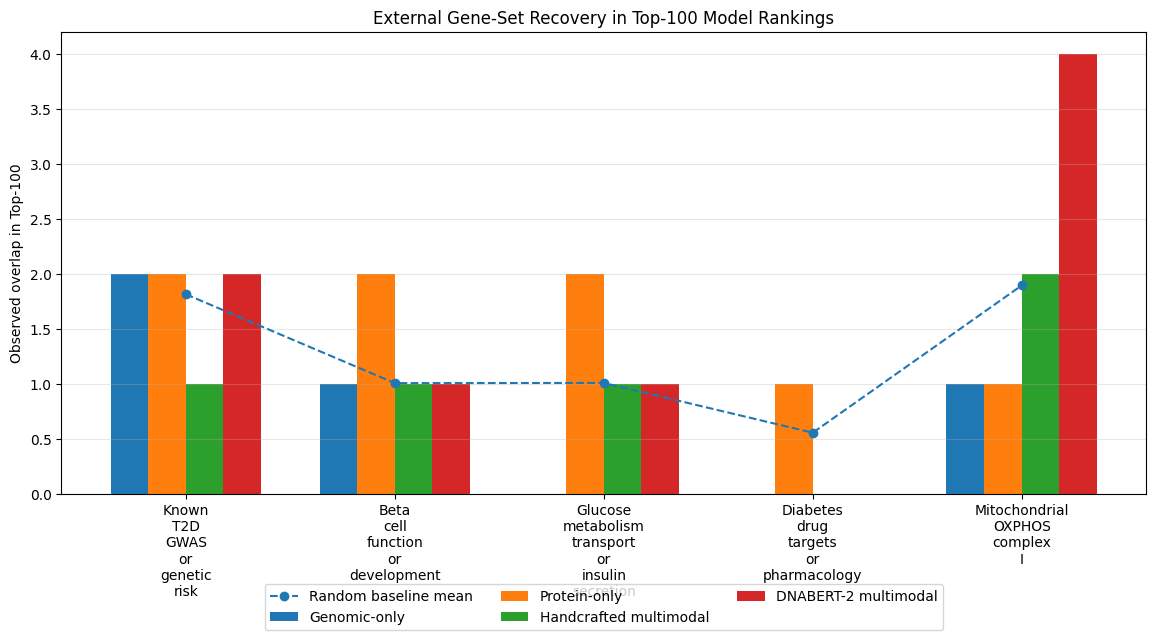

Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/figures/phase19_top100_external_gene_set_overlap.png


In [12]:
# ============================================================
# FIGURE 1 — TOP-N OVERLAP SUMMARY
# ============================================================

PLOT_TOP_N = 100

plot_df = topn_overlap_df[topn_overlap_df["top_n"] == PLOT_TOP_N].copy()

# Keep most interpretable external sets
external_order = [
    "Known_T2D_GWAS_or_genetic_risk",
    "Beta_cell_function_or_development",
    "Glucose_metabolism_transport_or_insulin_secretion",
    "Diabetes_drug_targets_or_pharmacology",
    "Mitochondrial_OXPHOS_complex_I"
]

plot_df = plot_df[plot_df["external_set"].isin(external_order)].copy()

model_order = [
    "Genomic-only",
    "Protein-only",
    "Handcrafted multimodal",
    "DNABERT-2 multimodal"
]

x_labels = external_order
x = np.arange(len(x_labels))
width = 0.18

plt.figure(figsize=(14, 6))

for i, model_display in enumerate(model_order):
    sub = plot_df[plot_df["display_name"] == model_display]

    values = []
    baseline = []

    for ext in x_labels:
        row = sub[sub["external_set"] == ext]
        if row.empty:
            values.append(np.nan)
            baseline.append(np.nan)
        else:
            values.append(float(row["observed_overlap"].iloc[0]))
            baseline.append(float(row["random_mean"].iloc[0]))

    plt.bar(
        x + (i - 1.5) * width,
        values,
        width=width,
        label=model_display
    )

# random baseline line per external set, averaged over models
baseline_means = (
    plot_df.groupby("external_set")["random_mean"]
    .mean()
    .reindex(x_labels)
    .values
)

plt.plot(x, baseline_means, marker="o", linestyle="--", label="Random baseline mean")

plt.xticks(x, [s.replace("_", "\n") for s in x_labels], rotation=0)
plt.ylabel(f"Observed overlap in Top-{PLOT_TOP_N}")
plt.title(f"External Gene-Set Recovery in Top-{PLOT_TOP_N} Model Rankings")
plt.grid(axis="y", alpha=0.3)
plt.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.18))

out_path = FIGURE_DIR / f"phase19_top{PLOT_TOP_N}_external_gene_set_overlap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

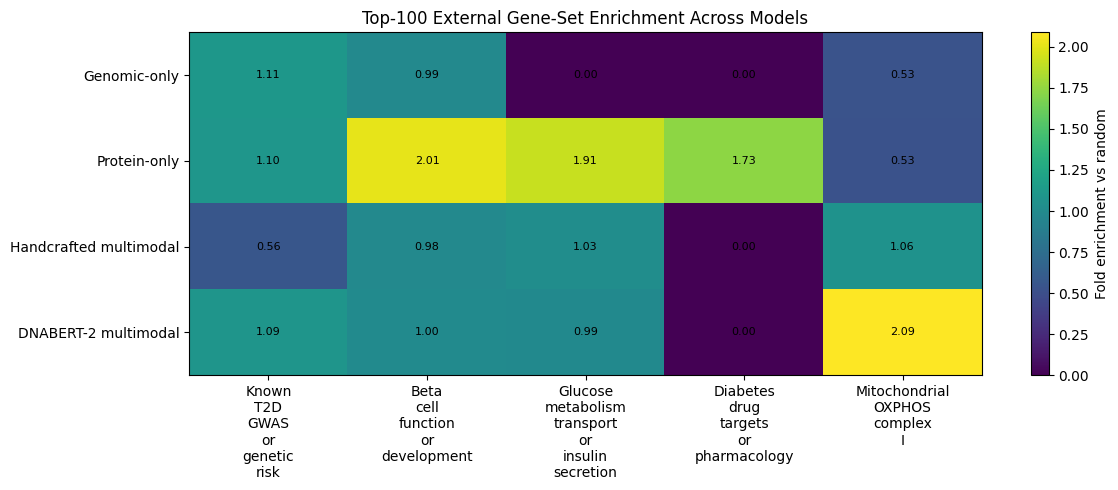

Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/figures/phase19_top100_external_enrichment_heatmap.png


In [13]:
# ============================================================
# FIGURE 2 — ENRICHMENT FOLD HEATMAP
# ============================================================

PLOT_TOP_N = 100

heat_df = topn_overlap_df[
    (topn_overlap_df["top_n"] == PLOT_TOP_N) &
    (topn_overlap_df["external_set"].isin(external_order))
].copy()

heat_pivot = heat_df.pivot_table(
    index="display_name",
    columns="external_set",
    values="enrichment_fold_vs_random"
).reindex(model_order)

heat_pivot = heat_pivot[[c for c in external_order if c in heat_pivot.columns]]

plt.figure(figsize=(12, 5))
plt.imshow(heat_pivot.values, aspect="auto")

plt.xticks(
    np.arange(heat_pivot.shape[1]),
    [c.replace("_", "\n") for c in heat_pivot.columns],
    rotation=0
)
plt.yticks(np.arange(heat_pivot.shape[0]), heat_pivot.index)

plt.colorbar(label="Fold enrichment vs random")
plt.title(f"Top-{PLOT_TOP_N} External Gene-Set Enrichment Across Models")

for i in range(heat_pivot.shape[0]):
    for j in range(heat_pivot.shape[1]):
        val = heat_pivot.values[i, j]
        if not np.isnan(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()

out_path = FIGURE_DIR / f"phase19_top{PLOT_TOP_N}_external_enrichment_heatmap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

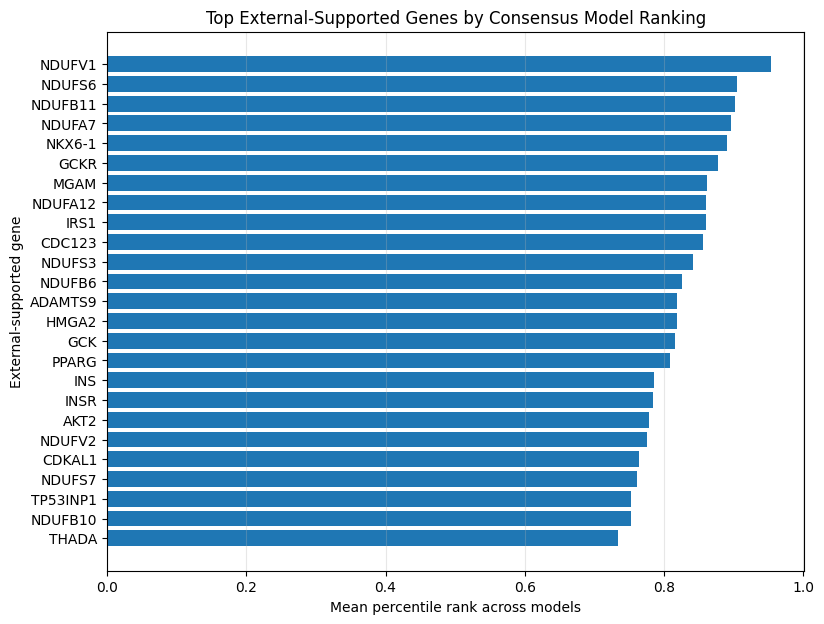

Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/figures/phase19_consensus_top_external_supported_genes.png


In [14]:
# ============================================================
# FIGURE 3 — CONSENSUS TOP EXTERNAL-SUPPORTED GENES
# ============================================================

top_external_plot_df = consensus_external_top_df.head(25).copy()

plt.figure(figsize=(9, 7))
plt.barh(
    top_external_plot_df["gene_symbol"][::-1],
    top_external_plot_df["mean_percentile_rank"][::-1]
)
plt.xlabel("Mean percentile rank across models")
plt.ylabel("External-supported gene")
plt.title("Top External-Supported Genes by Consensus Model Ranking")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase19_consensus_top_external_supported_genes.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [15]:
# ============================================================
# MANUSCRIPT-READY SUMMARY TABLES
# ============================================================

# Compact Top-100 external validation table
manuscript_top100_df = topn_overlap_df[
    (topn_overlap_df["top_n"] == 100) &
    (topn_overlap_df["external_set"].isin(external_order))
].copy()

manuscript_top100_df = manuscript_top100_df[[
    "display_name",
    "external_set",
    "observed_overlap",
    "random_mean",
    "enrichment_fold_vs_random",
    "empirical_p",
    "empirical_bh_fdr_within_topn",
    "top_genes_overlap"
]].sort_values(
    ["external_set", "display_name"]
)

manuscript_top100_df = round_numeric_columns(manuscript_top100_df, 4)

display(manuscript_top100_df)

save_df(manuscript_top100_df, RESULT_DIR / "phase19_manuscript_top100_external_validation_table.csv")

# Compact consensus candidate table
compact_consensus_df = consensus_external_top_df.head(30)[[
    "gene_symbol",
    "true_label",
    "consensus_rank",
    "mean_percentile_rank",
    "best_rank",
    "n_external_sets",
    "external_sets"
]].copy()

compact_consensus_df = round_numeric_columns(compact_consensus_df, 4)

display(compact_consensus_df)

save_df(compact_consensus_df, RESULT_DIR / "phase19_manuscript_consensus_external_supported_genes.csv")

,display_name,external_set,observed_overlap,random_mean,enrichment_fold_vs_random,empirical_p,empirical_bh_fdr_within_topn,top_genes_overlap
2,DNABERT-2 multimodal,Beta_cell_function_or_development,1,1.0006,0.9994,0.6387,1.0,NKX6-1
27,Genomic-only,Beta_cell_function_or_development,1,1.0138,0.9864,0.6481,1.0,HNF1B
52,Handcrafted multimodal,Beta_cell_function_or_development,1,1.0162,0.9841,0.6525,1.0,NKX6-1
77,Protein-only,Beta_cell_function_or_development,2,0.9956,2.0088,0.2666,1.0,GCK; NKX6-1
7,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology,0,0.5500,0.0000,1.0000,1.0,
32,Genomic-only,Diabetes_drug_targets_or_pharmacology,0,0.5320,0.0000,1.0000,1.0,
57,Handcrafted multimodal,Diabetes_drug_targets_or_pharmacology,0,0.5642,0.0000,1.0000,1.0,
82,Protein-only,Diabetes_drug_targets_or_pharmacology,1,0.5770,1.7331,0.4505,1.0,GCK
12,DNABERT-2 multimodal,Glucose_metabolism_transport_or_insulin_secretion,1,1.0058,0.9942,0.6493,1.0,GCKR
37,Genomic-only,Glucose_metabolism_transport_or_insulin_secretion,0,1.0078,0.0000,1.0000,1.0,


Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_manuscript_top100_external_validation_table.csv


,gene_symbol,true_label,consensus_rank,mean_percentile_rank,best_rank,n_external_sets,external_sets
0,NDUFV1,0,22,0.9537,28,1,Mitochondrial_OXPHOS_complex_I
1,NDUFS6,1,90,0.9051,120,1,Mitochondrial_OXPHOS_complex_I
2,NDUFB11,1,95,0.9012,55,1,Mitochondrial_OXPHOS_complex_I
3,NDUFA7,1,107,0.8958,28,1,Mitochondrial_OXPHOS_complex_I
4,NKX6-1,1,115,0.8900,23,1,Beta_cell_function_or_development
5,GCKR,1,131,0.8769,6,2,Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk
6,MGAM,1,156,0.8615,130,1,Diabetes_drug_targets_or_pharmacology
7,NDUFA12,0,158,0.8600,30,1,Mitochondrial_OXPHOS_complex_I
8,IRS1,1,159,0.8598,117,2,Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk
9,CDC123,1,168,0.8558,48,1,Known_T2D_GWAS_or_genetic_risk


Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_manuscript_consensus_external_supported_genes.csv


In [16]:
# ============================================================
# MANUSCRIPT-READY WORDING
# ============================================================

# Find strongest Top-100 enrichments
top100 = topn_overlap_df[topn_overlap_df["top_n"] == 100].copy()
top100 = top100.sort_values("enrichment_fold_vs_random", ascending=False)

best_row = top100.iloc[0] if not top100.empty else None

methods_text = """
To provide an external validation layer beyond internal held-out performance, out-of-fold prediction scores from repeated cross-validation were aggregated at the gene level and compared with independently curated T2D-relevant gene sets. These external sets represented known T2D/GWAS loci, pancreatic beta-cell function, glucose metabolism and insulin secretion, diabetes pharmacology and mitochondrial/OXPHOS biology. For each model, top-ranked genes were compared with each external gene set at multiple top-N thresholds. Empirical random baselines were generated by sampling same-size gene sets from the candidate universe, and empirical p-values were adjusted using the Benjamini--Hochberg procedure.
""".strip()

if best_row is not None:
    results_text = f"""
External gene-set recovery provided an independent biological validation of the model rankings. Across top-N thresholds, the analysis measured whether externally supported T2D-relevant genes appeared more often in the top-ranked lists than expected under random sampling. The strongest Top-100 enrichment was observed for {best_row['external_set']} in the {best_row['display_name']} model, with {int(best_row['observed_overlap'])} observed genes compared with a random expectation of {best_row['random_mean']:.2f} genes. These results provide a complementary validation layer to the internal performance metrics by assessing whether model rankings recover independently supported biological knowledge.
""".strip()
else:
    results_text = """
External gene-set recovery was performed to assess whether independently supported T2D-relevant genes were prioritized above random expectation. The resulting enrichment and rank-distribution statistics provide a complementary validation layer to internal performance metrics.
""".strip()

discussion_text = """
The external gene-set validation should be interpreted as supportive rather than confirmatory. Because disease-gene labels are incomplete and some external genes may overlap with known positive evidence, this analysis does not prove causal novelty. Instead, it evaluates whether the ranking procedure recovers independently supported T2D biology and highlights potentially under-annotated candidates. Genes labelled negative in the current dataset but supported by external evidence should be treated as possible unknown positives or hypothesis-generating candidates, not as definitive model errors. This validation layer strengthens the biological plausibility of the framework and helps shift the study from pure predictive benchmarking toward interpretable gene prioritization.
""".strip()

wording_df = pd.DataFrame([
    {"section": "Methods - External Gene-Set Validation", "text": methods_text},
    {"section": "Results - External Gene-Set Recovery", "text": results_text},
    {"section": "Discussion - External Validation Interpretation", "text": discussion_text}
])

display(wording_df)

save_df(wording_df, RESULT_DIR / "phase19_manuscript_ready_wording.csv")

with open(REPORT_DIR / "phase19_manuscript_ready_wording.md", "w") as f:
    for _, row in wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved manuscript wording.")

,section,text
0,Methods - External Gene-Set Validation,"To provide an external validation layer beyond internal held-out performance, out-of-fold prediction scores from repeated cross-validation were aggregated at the gene level and compared with independently curated T2D-relevant gene sets. These external sets represented known T2D/GWAS loci, pancreatic beta-cell function, glucose metabolism and insulin secretion, diabetes pharmacology and mitocho..."
1,Results - External Gene-Set Recovery,"External gene-set recovery provided an independent biological validation of the model rankings. Across top-N thresholds, the analysis measured whether externally supported T2D-relevant genes appeared more often in the top-ranked lists than expected under random sampling. The strongest Top-100 enrichment was observed for Mitochondrial_OXPHOS_complex_I in the DNABERT-2 multimodal model, with 4 o..."
2,Discussion - External Validation Interpretation,"The external gene-set validation should be interpreted as supportive rather than confirmatory. Because disease-gene labels are incomplete and some external genes may overlap with known positive evidence, this analysis does not prove causal novelty. Instead, it evaluates whether the ranking procedure recovers independently supported T2D biology and highlights potentially under-annotated candida..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_manuscript_ready_wording.csv
Saved manuscript wording.


In [17]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase19_external_independent_gene_set_validation_tables.xlsx"

tables = {
    "Sample_Metadata": sample_metadata_df,
    "Phase17_Predictions": phase17_pred_df,
    "Gene_Rankings": gene_rank_df,
    "External_Gene_Sets": external_gene_set_df,
    "External_Coverage": external_coverage_df,
    "TopN_Overlap": topn_overlap_df,
    "Rank_Distribution": rank_distribution_df,
    "External_Ranked": external_rank_annotated_df,
    "External_Negative_Candidates": external_negative_candidates_df,
    "Consensus_Ranking": consensus_df,
    "Consensus_External_Top": consensus_external_top_df,
    "Manuscript_Top100": manuscript_top100_df,
    "Manuscript_Consensus": compact_consensus_df,
    "Wording": wording_df
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/excel/phase19_external_independent_gene_set_validation_tables.xlsx


In [18]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 19 COMPLETE ===")

print("\nExternal gene-set coverage:")
display(external_coverage_df)

print("\nTop-100 external validation table:")
display(manuscript_top100_df)

print("\nRank-distribution tests:")
display(rank_distribution_df)

print("\nTop consensus external-supported genes:")
display(compact_consensus_df.head(30))

print("\nExternal-supported current-negative candidates:")
display(external_negative_candidates_df.head(50))

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(p)

print("\nResults:")
for p in sorted(RESULT_DIR.glob("*.csv")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*.xlsx")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== PHASE 19 COMPLETE ===

External gene-set coverage:


,external_set,n_external_genes,n_in_candidate_universe,genes_in_candidate_universe,coverage_rate
0,Beta_cell_function_or_development,22,18,ABCC8; CACNA1D; GAD1; GCK; GLIS3; HNF1A; HNF1B; HNF4A; INS; ISL1; KCNJ11; MTNR1B; NEUROD1; NKX6-1; PAX4; PCSK1; PDX1; SLC30A8,0.8182
1,Diabetes_drug_targets_or_pharmacology,12,10,ABCC8; DPP4; GCK; GIPR; GLP1R; INSR; KCNJ11; MGAM; PPARG; SLC5A2,0.8333
2,Glucose_metabolism_transport_or_insulin_secretion,21,18,ABCC8; AKT2; DPP4; G6PC2; GCK; GCKR; GIPR; GLP1R; HK1; INSR; IRS1; IRS2; KCNJ11; PCSK1; PIK3R1; SLC2A2; SLC5A1; SLC5A2,0.8571
3,Known_T2D_GWAS_or_genetic_risk,35,33,ADAMTS9; ADCY5; CAMK1D; CDC123; CDKAL1; CDKN2B; DGKB; DUSP9; FTO; GCK; GCKR; GIPR; GLIS3; GRB14; HHEX; HMGA2; IGF2BP2; INSR; IRS1; JAZF1; KCNJ11; KCNQ1; MAEA; MTNR1B; NOTCH2; PPARG; PROX1; SLC30A8; TCF7L2; THADA; TP53INP1; TSPAN8; WFS1,0.9429
4,Mitochondrial_OXPHOS_complex_I,35,34,NDUFA1; NDUFA10; NDUFA11; NDUFA12; NDUFA13; NDUFA2; NDUFA3; NDUFA5; NDUFA6; NDUFA7; NDUFA8; NDUFA9; NDUFB1; NDUFB10; NDUFB11; NDUFB2; NDUFB3; NDUFB4; NDUFB5; NDUFB6; NDUFB7; NDUFB8; NDUFB9; NDUFS1; NDUFS2; NDUFS3; NDUFS4; NDUFS5; NDUFS6; NDUFS7; NDUFS8; NDUFV1; NDUFV2; NDUFV3,0.9714



Top-100 external validation table:


,display_name,external_set,observed_overlap,random_mean,enrichment_fold_vs_random,empirical_p,empirical_bh_fdr_within_topn,top_genes_overlap
2,DNABERT-2 multimodal,Beta_cell_function_or_development,1,1.0006,0.9994,0.6387,1.0,NKX6-1
27,Genomic-only,Beta_cell_function_or_development,1,1.0138,0.9864,0.6481,1.0,HNF1B
52,Handcrafted multimodal,Beta_cell_function_or_development,1,1.0162,0.9841,0.6525,1.0,NKX6-1
77,Protein-only,Beta_cell_function_or_development,2,0.9956,2.0088,0.2666,1.0,GCK; NKX6-1
7,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology,0,0.5500,0.0000,1.0000,1.0,
32,Genomic-only,Diabetes_drug_targets_or_pharmacology,0,0.5320,0.0000,1.0000,1.0,
57,Handcrafted multimodal,Diabetes_drug_targets_or_pharmacology,0,0.5642,0.0000,1.0000,1.0,
82,Protein-only,Diabetes_drug_targets_or_pharmacology,1,0.5770,1.7331,0.4505,1.0,GCK
12,DNABERT-2 multimodal,Glucose_metabolism_transport_or_insulin_secretion,1,1.0058,0.9942,0.6493,1.0,GCKR
37,Genomic-only,Glucose_metabolism_transport_or_insulin_secretion,0,1.0078,0.0000,1.0000,1.0,



Rank-distribution tests:


...


Top consensus external-supported genes:


,gene_symbol,true_label,consensus_rank,mean_percentile_rank,best_rank,n_external_sets,external_sets
0,NDUFV1,0,22,0.9537,28,1,Mitochondrial_OXPHOS_complex_I
1,NDUFS6,1,90,0.9051,120,1,Mitochondrial_OXPHOS_complex_I
2,NDUFB11,1,95,0.9012,55,1,Mitochondrial_OXPHOS_complex_I
3,NDUFA7,1,107,0.8958,28,1,Mitochondrial_OXPHOS_complex_I
4,NKX6-1,1,115,0.8900,23,1,Beta_cell_function_or_development
5,GCKR,1,131,0.8769,6,2,Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk
6,MGAM,1,156,0.8615,130,1,Diabetes_drug_targets_or_pharmacology
7,NDUFA12,0,158,0.8600,30,1,Mitochondrial_OXPHOS_complex_I
8,IRS1,1,159,0.8598,117,2,Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk
9,CDC123,1,168,0.8558,48,1,Known_T2D_GWAS_or_genetic_risk



External-supported current-negative candidates:


,sample_index,gene_symbol,true_label,mean_oof_score,sd_oof_score,n_oof_predictions,model_name,rank_desc,percentile_rank,display_name,external_sets,n_external_sets,is_current_negative,is_current_positive
0,268,NDUFV1,0,0.808844,0.037659,5,DNABERT2_multimodal,95,0.947922,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
1,585,NDUFA12,0,0.806018,0.030543,5,DNABERT2_multimodal,98,0.946260,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
2,628,NDUFB10,0,0.762450,0.041657,5,DNABERT2_multimodal,198,0.890859,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
3,514,NDUFB5,0,0.700973,0.068433,5,DNABERT2_multimodal,354,0.804432,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
4,810,GIPR,0,0.679566,0.044854,5,DNABERT2_multimodal,408,0.774515,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk,3,True,False
5,607,NDUFA9,0,0.672797,0.047920,5,DNABERT2_multimodal,428,0.763435,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
6,403,NDUFA10,0,0.661107,0.067310,5,DNABERT2_multimodal,456,0.747922,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
7,727,NDUFS7,0,0.613066,0.043973,5,DNABERT2_multimodal,591,0.673130,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
8,328,NDUFB4,0,0.610561,0.057368,5,DNABERT2_multimodal,596,0.670360,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False
9,320,NDUFB8,0,0.597424,0.072656,5,DNABERT2_multimodal,633,0.649861,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,1,True,False



Figures:
/content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/figures/phase19_consensus_top_external_supported_genes.png
/content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/figures/phase19_top100_external_enrichment_heatmap.png
/content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/figures/phase19_top100_external_gene_set_overlap.png

Results:
/content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_consensus_external_supported_top_genes.csv
/content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_consensus_gene_ranking_across_models.csv
/content/drive/MyDrive/Project_Protein/model/phase19_external_independent_gene_set_validation/results/phase19_external_gene_rank_distribution_tests.csv
/content/drive/MyDrive/Project_Protein/model/phase19_external_independent_g

In [19]:
display(external_coverage_df)

display(manuscript_top100_df)

display(rank_distribution_df[[
    "display_name",
    "external_set",
    "n_external_in_universe",
    "mean_score_external",
    "mean_score_non_external",
    "median_rank_external",
    "median_rank_non_external",
    "mannwhitney_score_p",
    "score_bh_fdr"
]])

display(compact_consensus_df.head(30))

display(external_negative_candidates_df[[
    "gene_symbol",
    "true_label",
    "model_name",
    "display_name",
    "rank_desc",
    "mean_oof_score",
    "n_external_sets",
    "external_sets"
]].head(50))

,external_set,n_external_genes,n_in_candidate_universe,genes_in_candidate_universe,coverage_rate
0,Beta_cell_function_or_development,22,18,ABCC8; CACNA1D; GAD1; GCK; GLIS3; HNF1A; HNF1B; HNF4A; INS; ISL1; KCNJ11; MTNR1B; NEUROD1; NKX6-1; PAX4; PCSK1; PDX1; SLC30A8,0.8182
1,Diabetes_drug_targets_or_pharmacology,12,10,ABCC8; DPP4; GCK; GIPR; GLP1R; INSR; KCNJ11; MGAM; PPARG; SLC5A2,0.8333
2,Glucose_metabolism_transport_or_insulin_secretion,21,18,ABCC8; AKT2; DPP4; G6PC2; GCK; GCKR; GIPR; GLP1R; HK1; INSR; IRS1; IRS2; KCNJ11; PCSK1; PIK3R1; SLC2A2; SLC5A1; SLC5A2,0.8571
3,Known_T2D_GWAS_or_genetic_risk,35,33,ADAMTS9; ADCY5; CAMK1D; CDC123; CDKAL1; CDKN2B; DGKB; DUSP9; FTO; GCK; GCKR; GIPR; GLIS3; GRB14; HHEX; HMGA2; IGF2BP2; INSR; IRS1; JAZF1; KCNJ11; KCNQ1; MAEA; MTNR1B; NOTCH2; PPARG; PROX1; SLC30A8; TCF7L2; THADA; TP53INP1; TSPAN8; WFS1,0.9429
4,Mitochondrial_OXPHOS_complex_I,35,34,NDUFA1; NDUFA10; NDUFA11; NDUFA12; NDUFA13; NDUFA2; NDUFA3; NDUFA5; NDUFA6; NDUFA7; NDUFA8; NDUFA9; NDUFB1; NDUFB10; NDUFB11; NDUFB2; NDUFB3; NDUFB4; NDUFB5; NDUFB6; NDUFB7; NDUFB8; NDUFB9; NDUFS1; NDUFS2; NDUFS3; NDUFS4; NDUFS5; NDUFS6; NDUFS7; NDUFS8; NDUFV1; NDUFV2; NDUFV3,0.9714


,display_name,external_set,observed_overlap,random_mean,enrichment_fold_vs_random,empirical_p,empirical_bh_fdr_within_topn,top_genes_overlap
2,DNABERT-2 multimodal,Beta_cell_function_or_development,1,1.0006,0.9994,0.6387,1.0,NKX6-1
27,Genomic-only,Beta_cell_function_or_development,1,1.0138,0.9864,0.6481,1.0,HNF1B
52,Handcrafted multimodal,Beta_cell_function_or_development,1,1.0162,0.9841,0.6525,1.0,NKX6-1
77,Protein-only,Beta_cell_function_or_development,2,0.9956,2.0088,0.2666,1.0,GCK; NKX6-1
7,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology,0,0.5500,0.0000,1.0000,1.0,
32,Genomic-only,Diabetes_drug_targets_or_pharmacology,0,0.5320,0.0000,1.0000,1.0,
57,Handcrafted multimodal,Diabetes_drug_targets_or_pharmacology,0,0.5642,0.0000,1.0000,1.0,
82,Protein-only,Diabetes_drug_targets_or_pharmacology,1,0.5770,1.7331,0.4505,1.0,GCK
12,DNABERT-2 multimodal,Glucose_metabolism_transport_or_insulin_secretion,1,1.0058,0.9942,0.6493,1.0,GCKR
37,Genomic-only,Glucose_metabolism_transport_or_insulin_secretion,0,1.0078,0.0000,1.0000,1.0,


,display_name,external_set,n_external_in_universe,mean_score_external,mean_score_non_external,median_rank_external,median_rank_non_external,mannwhitney_score_p,score_bh_fdr
0,DNABERT-2 multimodal,Beta_cell_function_or_development,18,0.45146,0.50013,1127.0,900.5,0.28137,0.70708
1,DNABERT-2 multimodal,Diabetes_drug_targets_or_pharmacology,10,0.53832,0.49943,552.5,904.5,0.50493,0.70708
2,DNABERT-2 multimodal,Glucose_metabolism_transport_or_insulin_secretion,18,0.47836,0.49986,1162.5,901.5,0.63194,0.70708
3,DNABERT-2 multimodal,Known_T2D_GWAS_or_genetic_risk,33,0.51852,0.49929,891.0,904.0,0.55706,0.70708
4,DNABERT-2 multimodal,Mitochondrial_OXPHOS_complex_I,34,0.54372,0.49880,665.5,907.5,0.18533,0.70708
5,Genomic-only,Beta_cell_function_or_development,18,0.51520,0.50070,681.5,906.5,0.36699,0.70708
6,Genomic-only,Diabetes_drug_targets_or_pharmacology,10,0.51659,0.50076,702.0,905.5,0.51901,0.70708
7,Genomic-only,Glucose_metabolism_transport_or_insulin_secretion,18,0.47599,0.50110,806.5,904.5,0.45643,0.70708
8,Genomic-only,Known_T2D_GWAS_or_genetic_risk,33,0.50845,0.50071,827.0,905.0,0.63489,0.70708
9,Genomic-only,Mitochondrial_OXPHOS_complex_I,34,0.48456,0.50116,984.0,900.5,0.35663,0.70708


,gene_symbol,true_label,consensus_rank,mean_percentile_rank,best_rank,n_external_sets,external_sets
0,NDUFV1,0,22,0.9537,28,1,Mitochondrial_OXPHOS_complex_I
1,NDUFS6,1,90,0.9051,120,1,Mitochondrial_OXPHOS_complex_I
2,NDUFB11,1,95,0.9012,55,1,Mitochondrial_OXPHOS_complex_I
3,NDUFA7,1,107,0.8958,28,1,Mitochondrial_OXPHOS_complex_I
4,NKX6-1,1,115,0.8900,23,1,Beta_cell_function_or_development
5,GCKR,1,131,0.8769,6,2,Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk
6,MGAM,1,156,0.8615,130,1,Diabetes_drug_targets_or_pharmacology
7,NDUFA12,0,158,0.8600,30,1,Mitochondrial_OXPHOS_complex_I
8,IRS1,1,159,0.8598,117,2,Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk
9,CDC123,1,168,0.8558,48,1,Known_T2D_GWAS_or_genetic_risk


,gene_symbol,true_label,model_name,display_name,rank_desc,mean_oof_score,n_external_sets,external_sets
0,NDUFV1,0,DNABERT2_multimodal,DNABERT-2 multimodal,95,0.808844,1,Mitochondrial_OXPHOS_complex_I
1,NDUFA12,0,DNABERT2_multimodal,DNABERT-2 multimodal,98,0.806018,1,Mitochondrial_OXPHOS_complex_I
2,NDUFB10,0,DNABERT2_multimodal,DNABERT-2 multimodal,198,0.762450,1,Mitochondrial_OXPHOS_complex_I
3,NDUFB5,0,DNABERT2_multimodal,DNABERT-2 multimodal,354,0.700973,1,Mitochondrial_OXPHOS_complex_I
4,GIPR,0,DNABERT2_multimodal,DNABERT-2 multimodal,408,0.679566,3,Diabetes_drug_targets_or_pharmacology; Glucose_metabolism_transport_or_insulin_secretion; Known_T2D_GWAS_or_genetic_risk
5,NDUFA9,0,DNABERT2_multimodal,DNABERT-2 multimodal,428,0.672797,1,Mitochondrial_OXPHOS_complex_I
6,NDUFA10,0,DNABERT2_multimodal,DNABERT-2 multimodal,456,0.661107,1,Mitochondrial_OXPHOS_complex_I
7,NDUFS7,0,DNABERT2_multimodal,DNABERT-2 multimodal,591,0.613066,1,Mitochondrial_OXPHOS_complex_I
8,NDUFB4,0,DNABERT2_multimodal,DNABERT-2 multimodal,596,0.610561,1,Mitochondrial_OXPHOS_complex_I
9,NDUFB8,0,DNABERT2_multimodal,DNABERT-2 multimodal,633,0.597424,1,Mitochondrial_OXPHOS_complex_I
